In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0
df = pd.concat([df, df1], ignore_index=True)
#df = df.append(df1,ignore_index=True)

df = df.sample(40)

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [8]:
import numpy as np
import pandas as pd

# Assume 'df' is the dataframe with 3 features from our previous steps
# We only want the features for PCA, not the 'target' label
X = df.iloc[:, 0:3].values

In [11]:
print(X[:5])

[[-0.36754812 -1.13745969 -1.32214752]
 [ 0.17706132 -0.59810911  1.22651174]
 [ 0.42062266  0.41161964 -0.07132392]
 [ 1.96843473 -0.54778801 -0.67941827]
 [-2.50623032  0.14696049  0.60619549]]


In [12]:
# 1. Mean Center the Data
# Subtract the mean of each column from the data points
mu = np.mean(X, axis=0)
X_centered = X - mu

In [13]:
print(X_centered[:5])

[[-0.80126954 -1.59824934 -1.98981796]
 [-0.2566601  -1.05889876  0.5588413 ]
 [-0.01309876 -0.04917001 -0.73899436]
 [ 1.53471331 -1.00857766 -1.34708871]
 [-2.93995174 -0.31382915 -0.06147495]]


In [14]:
# 2. Compute Covariance Matrix
# Using the formula: (1 / n-1) * X_transpose * X
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

In [16]:
print(cov_matrix)

[[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]


In [17]:
# 3 & 4. Compute Eigenvalues and Eigenvectors
# The equation is Cv = λv
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [18]:
print(eigenvalues)
print(eigenvectors)

[1.65691289 1.22963722 0.90717381]
[[-0.61002583 -0.69239396  0.3853039 ]
 [-0.53982115  0.00718615 -0.84174906]
 [-0.58005311  0.72148387  0.37815264]]


In [19]:
# 5. Normalize Eigenvectors
# np.linalg.eig already returns unit eigenvectors (length = 1), 
# but we can ensure it manually if needed:
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

In [20]:
print(eigenvectors)

[[-0.61002583 -0.69239396  0.3853039 ]
 [-0.53982115  0.00718615 -0.84174906]
 [-0.58005311  0.72148387  0.37815264]]


In [21]:
# 6. Sort Eigenvalues (Descending)
# Get the indices that would sort the eigenvalues from largest to smallest
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [23]:
print(eigenvalues)
#print(eigenvectors)

[1.65691289 1.22963722 0.90717381]


In [24]:
# 7. Select Top k Eigenvectors
# Let's say we want to reduce 3D data down to 2D
k = 2
Vk = eigenvectors[:, :k]

In [25]:
print(Vk)

[[-0.61002583 -0.69239396]
 [-0.53982115  0.00718615]
 [-0.58005311  0.72148387]]


In [26]:
# 8. Project Data
# X_reduced = X_centered dot Vk
X_reduced = X_centered @ Vk

In [27]:
# --- Verification ---
print("Original Shape:", X.shape)
print("Reduced Shape:", X_reduced.shape)
print("\nTop 2 Eigenvalues (Variance explained):\n", eigenvalues[:k])

Original Shape: (40, 3)
Reduced Shape: (40, 2)

Top 2 Eigenvalues (Variance explained):
 [1.65691289 1.22963722]


In [28]:
print(X_reduced[:5])

[[ 2.50576401 -0.89231263]
 [ 0.40402761  0.57329548]
 [ 0.46318957 -0.52445635]
 [ 0.38961979 -2.04177678]
 [ 1.99851685  1.98899641]]


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


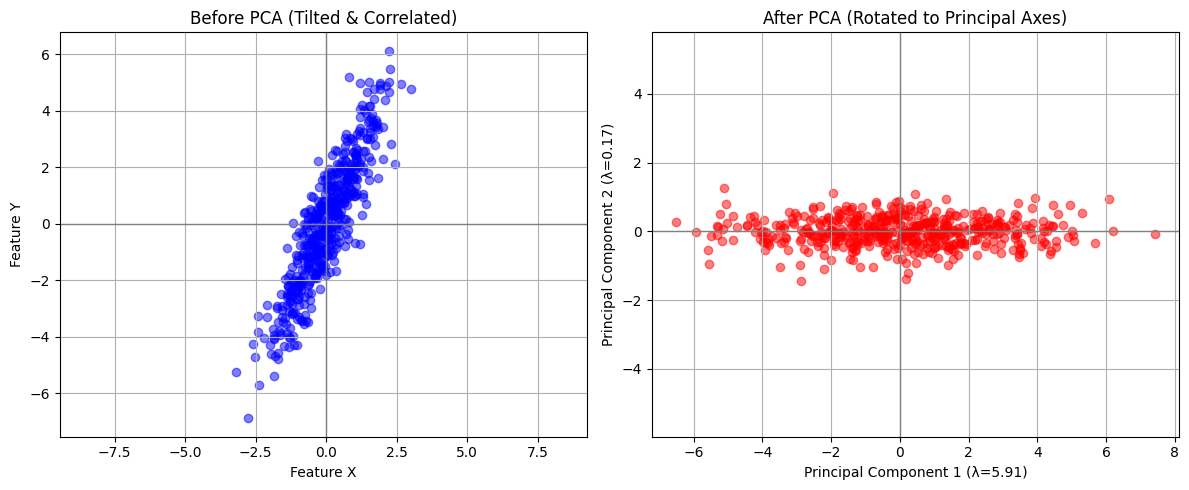

In [29]:
%pylab inline
import numpy as np
import matplotlib.pyplot as plt

# --- PREPARE DATA ---
np.random.seed(123)

# 1. Start with independent data (mean 0, variance 1)
x = np.random.normal(0, 1, 500)
y = np.random.normal(0, 1, 500)

# 2. "Tilt" the data to create correlation
# New Y depends heavily on X, creating a diagonal stretch
y_correlated = 2*x + y

# Stack them into a 2D data matrix (X and Y are features, not target)
data = np.vstack((x, y_correlated)).T
X = data

# --- PERFORM PCA STEPS (from your list) ---

# 1. Mean Center the Data
mu = np.mean(X, axis=0)
X_centered = X - mu

# 2. Compute Covariance Matrix
cov_matrix = np.cov(X_centered.T)

# 3, 4, 5. Compute Eigenvalues/vectors & Normalize
# linalg.eig returns unit eigenvectors automatically
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 6. Sort Eigenvalues (Descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 7. Select Top k (in this case, all 2 for 2D rotation)
Vk = eigenvectors # Use both vectors for full rotation

# 8. Project (ROTATE) the Data
# X_rotated = X_centered @ Vk
X_rotated = X_centered @ Vk


# --- PLOTTING ---
plt.figure(figsize=(12, 5))

# Plot 1: Before PCA (Original, Tilted Data)
plt.subplot(1, 2, 1)
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, color='blue', label='Data')
plt.axhline(0, color='grey', lw=1); plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.axis('equal') # Crucial to see actual angles
plt.title('Before PCA (Tilted & Correlated)')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')

# Plot 2: After PCA (Rotated Data)
plt.subplot(1, 2, 2)
# X_rotated[:, 0] is the 1st Principal Component
# X_rotated[:, 1] is the 2nd Principal Component
plt.scatter(X_rotated[:, 0], X_rotated[:, 1], alpha=0.5, color='red', label='PCA Data')
plt.axhline(0, color='grey', lw=1); plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.axis('equal')
plt.title('After PCA (Rotated to Principal Axes)')
plt.xlabel('Principal Component 1 (λ=%.2f)' % eigenvalues[0])
plt.ylabel('Principal Component 2 (λ=%.2f)' % eigenvalues[1])

plt.tight_layout()
plt.show()